In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models
import shap
from PIL import Image
from tqdm import tqdm


d:\AI Mini project (AI vs Real image)\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset

In [3]:
data_dir = r"D:\AI Mini project (AI vs Real image)\archive"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
test_data  = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

# Split training into train & validation
train_size = int(0.8 * len(train_data))
val_size   = len(train_data) - train_size
train_set, val_set = random_split(train_data, [train_size, val_size])

# Handle class imbalance (novelty 4)

In [5]:
class_counts = np.bincount([y for _, y in train_set])
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [weights[y] for _, y in train_set]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_set, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"✅ Data Loaded: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_data)}")


✅ Data Loaded: Train=80000, Val=20000, Test=20000


# 2️ Model: Fine-Tuned ResNet18 (novelty 3️)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # freeze base layers

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2),  # real vs fake
    nn.Softmax(dim=1)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

d:\AI Mini project (AI vs Real image)\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\AI Mini project (AI vs Real image)\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Acer/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 11.1MB/s]


# 3️ Training Loop

In [8]:
def train_model(model, train_loader, val_loader, epochs=5):
    train_loss, val_loss = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train = running_loss / len(train_loader)
        train_loss.append(avg_train)

        # Validation
        model.eval()
        val_running = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                val_running += criterion(model(X), y).item()
        avg_val = val_running / len(val_loader)
        val_loss.append(avg_val)
        print(f"Epoch {epoch+1}: Train Loss={avg_train:.4f}, Val Loss={avg_val:.4f}")

    return train_loss, val_loss

train_model(model, train_loader, val_loader)

Epoch 1/5:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 2500/2500 [33:19<00:00,  1.25it/s]


Epoch 1: Train Loss=0.4677, Val Loss=0.4439


Epoch 2/5: 100%|██████████| 2500/2500 [34:22<00:00,  1.21it/s]


Epoch 2: Train Loss=0.4441, Val Loss=0.4257


...

Epoch 4/5: 100%|██████████| 2500/2500 [28:28<00:00,  1.46it/s]


Epoch 4: Train Loss=0.4309, Val Loss=0.4151


Epoch 5/5: 100%|██████████| 2500/2500 [27:49<00:00,  1.50it/s]


Epoch 5: Train Loss=0.4285, Val Loss=0.4158


([0.46770015333890913,
  0.4441245934963226,
  0.4370259713888168,
  0.4308702465891838,
  0.4285207418680191],
 [0.44394965834617617,
  0.425682248878479,
  0.42455489172935484,
  0.41511433281898497,
  0.41583262729644777])

# 4️ Evaluation (Accuracy)

In [9]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = torch.argmax(model(X), 1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

acc = evaluate(model, test_loader)
print(f"✅ Test Accuracy: {acc:.2f}%")

✅ Test Accuracy: 90.18%


5️ Explainability: Grad-CAM (novelty 1️⃣)

In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
model.to(device)





ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [37]:
def generate_gradcam(model, input_tensor, target_layer):
    model.eval()
    activations = {}
    gradients = {}

    # ---- forward hook ----
    def forward_hook(module, inp, out):
        activations["value"] = out
        # Register gradient hook directly on tensor output
        out.register_hook(lambda grad: gradients.setdefault("value", grad))

    # ---- register only the forward hook ----
    fwd_handle = target_layer.register_forward_hook(forward_hook)

    # forward pass
    input_tensor.requires_grad_()
    output = model(input_tensor)
    pred_class = output.argmax(dim=1)
    score = output[0, pred_class]
    model.zero_grad()

    # backward pass
    score.backward()

    # ---- compute Grad-CAM ----
    grad = gradients["value"]
    act = activations["value"]

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * act).sum(dim=1, keepdim=True))

    cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # remove hooks
    fwd_handle.remove()

    return cam, pred_class.item()



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


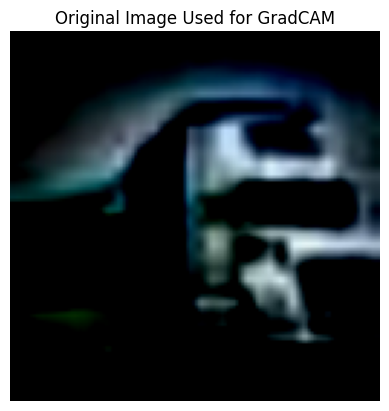

In [41]:
sample_img, label = next(iter(test_loader))
sample_img = sample_img[0:1].to(device)

import matplotlib.pyplot as plt
plt.imshow(np.transpose(sample_img[0].cpu().numpy(), (1, 2, 0)))
plt.title("Original Image Used for GradCAM")
plt.axis("off")
plt.show()


grad_cam, pred_class = generate_gradcam(model, sample_img, model.layer4)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


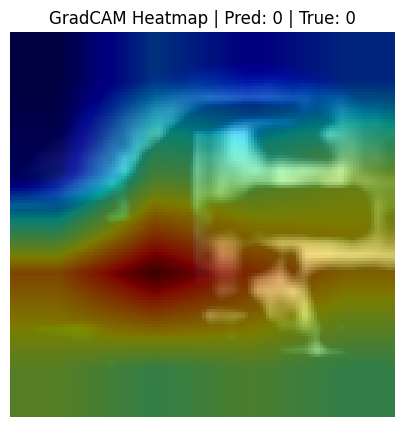

In [40]:
img = np.transpose(sample_img[0].detach().cpu().numpy(), (1, 2, 0))  # fixed line
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.imshow(grad_cam, cmap='jet', alpha=0.5)
plt.title(f"GradCAM Heatmap | Pred: {pred_class} | True: {label[0].item()}")
plt.axis('off')
plt.show()


In [42]:
# Get one batch
sample_batch = next(iter(test_loader))

# This contains image tensors and labels
images, labels = sample_batch

# Find the file paths using test_data.imgs
file_path = test_data.imgs[0][0]  # 0 means first image in dataset
print("🖼️ Image file used for Grad-CAM:", file_path)


🖼️ Image file used for Grad-CAM: D:\AI Mini project (AI vs Real image)\archive\test\FAKE\0 (10).jpg


# 7️ Robustness Testing (Novelty 3)

In [45]:
def test_robustness(model, loader):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            noisy_images = add_noise(images)
            images, labels = noisy_images.to(device), labels.to(device)

            # ⚙️ ensure inputs have grad enabled (fixes retain_grad issue)
            images.requires_grad_(True)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy under noise: {acc:.2f}%")

    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


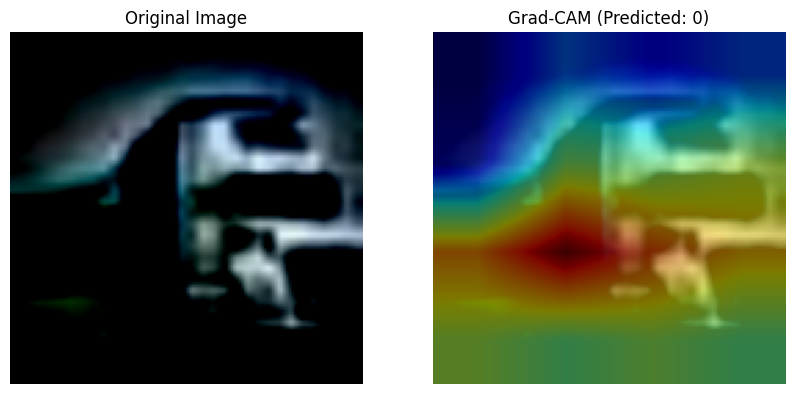

In [46]:
# Convert sample image to numpy for visualization
img = np.transpose(sample_img[0].detach().cpu().numpy(), (1, 2, 0))

# Plot Grad-CAM output
plt.figure(figsize=(10,5))

# Original image
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Grad-CAM overlay
plt.subplot(1,2,2)
plt.imshow(img)
plt.imshow(grad_cam, cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM (Predicted: {pred_class})")
plt.axis("off")

plt.show()


In [50]:
# %% [markdown]
# # Save the Trained Model State

# %%
model_save_path = "resnet18_cifake_classifier.pth"
torch.save(model.state_dict(), model_save_path)
print(f"✅ Model weights saved to: {model_save_path}")

✅ Model weights saved to: resnet18_cifake_classifier.pth
